In [67]:
from arch import arch_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox as lb

from sklearn.model_selection import train_test_split

import pmdarima as pm

stock = r'etf_series.hf5'

In [16]:
def evaluate_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    return "sMAPE :", np.mean(numerator/denominator) * 100

def evaluate_rmse(y_true, y_pred):
    squared_errors = (y_true - y_pred)**2
    rmse = np.sqrt(np.mean(squared_errors))
    return "RMSE (squared residuals vs predicted variance):", rmse

### Data Prep

In [2]:
XLE = pd.read_hdf(stock, key = "XLE")[["Adj Close"]].drop_duplicates()
XLE["Pct Returns"] = XLE["Adj Close"].pct_change()*100
XLE["Returns"] = XLE["Adj Close"].diff()
XLE = XLE.dropna()

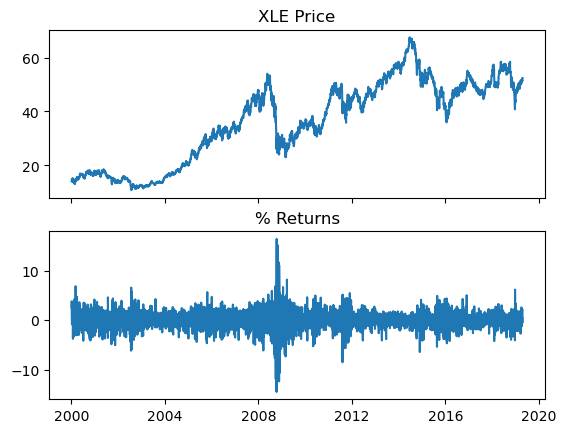

In [6]:
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(XLE_train["Adj Close"])
axs[0].set_title("XLE Price")
axs[1].plot(XLE_train["Pct Returns"])
axs[1].set_title(r"% Returns")

plt.show()

In [3]:
brent = pd.read_csv("brent.csv", index_col=0)
brent.index = pd.to_datetime(brent.index, dayfirst=True)
brent = brent.replace(".", np.nan).fillna(method="ffill")
brent_returns = brent.astype(float).pct_change()*100
brent_returns = brent_returns.dropna()

C:\Users\Dominique\AppData\Local\Temp\ipykernel_24300\1782272560.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  brent = brent.replace(".", np.nan).fillna(method="ffill")


In [29]:
print(XLE.loc["2020-03-20" : "2020-03-30"])
print(brent_returns.loc["2020-03-20" : "2020-03-30"])

            Adj Close  Pct Returns   Returns
Date                                        
2020-03-20  20.914873     0.976186  0.202194
2020-03-23  19.489349    -6.815837 -1.425524
2020-03-24  22.614923    16.037345  3.125574
2020-03-25  23.681583     4.716620  1.066660
2020-03-26  25.128607     6.110332  1.447023
2020-03-27  23.425255    -6.778537 -1.703352
2020-03-30  23.665049     1.023655  0.239794
                Price
Date                 
2020-03-20   6.547123
2020-03-23  -7.045010
2020-03-24   3.157895
2020-03-25   4.571429
2020-03-26  -8.079625
2020-03-27  -4.925690
2020-03-30 -14.292095


In [4]:
print(len(XLE))
print(len(brent_returns))
dates_XLE = set(XLE.index)
dates_brent = set(brent_returns.index)
common_dates = dates_XLE &  dates_brent
diff_dates = (dates_XLE | dates_brent) - common_dates

XLE = XLE[XLE.index.isin(common_dates)]
brent_returns = brent_returns[brent_returns.index.isin(common_dates)]

5693
6258


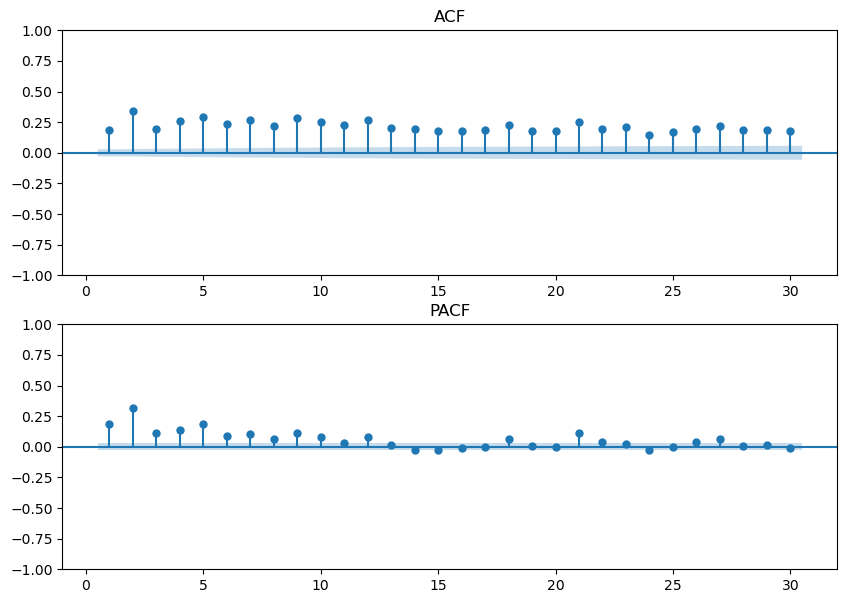

In [7]:
fig, axs = plt.subplots(2, figsize=(10,7))
plot_acf(XLE_train["Returns"]**2, ax=axs[0], lags = 30, zero = False, title="ACF", alpha = 0.05)
plot_pacf(XLE_train["Returns"]**2, ax=axs[1], lags = 30, zero = False, title="PACF", alpha = 0.05)

plt.show()

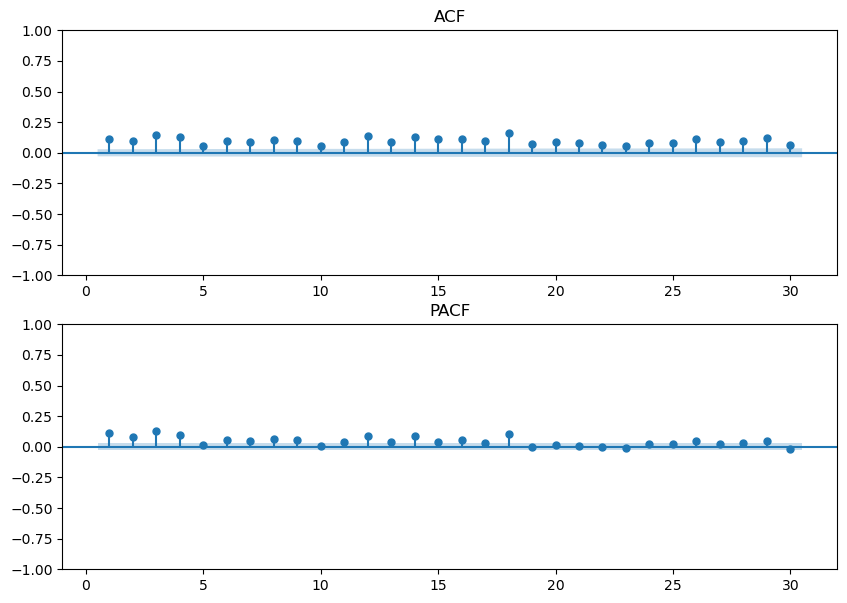

In [41]:
fig, axs = plt.subplots(2, figsize=(10,7))
plot_acf(brent_train**2, ax=axs[0], lags = 30, zero = False, title="ACF", alpha = 0.05)
plot_pacf(brent_train**2, ax=axs[1], lags = 30, zero = False, title="PACF", alpha = 0.05)

plt.show()

### 80-20 Train-Test Split

In [5]:
XLE_train, XLE_test = train_test_split(XLE, test_size = 0.2, shuffle=False)
brent_train, brent_test = train_test_split(brent_returns, test_size = 0.2, shuffle=False)

In [87]:
garch_model = arch_model(XLE_train["Returns"], x = brent_train, mean = "ARX", lags = 1, vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
fit = garch_model.fit(disp='off')
fit.summary()

c:\Users\Dominique\anaconda3\lib\site-packages\arch\univariate\base.py:1897: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(val[pos], np.float64):
c:\Users\Dominique\anaconda3\lib\site-packages\arch\univariate\base.py:1898: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  converted = format_float_fixed(val[pos], *formats[i])


<class 'statsmodels.iolib.summary.Summary'>
"""
                               AR-X - EGARCH Model Results                               
=========================================================================================
Dep. Variable:                           Returns   R-squared:                       0.099
Mean Model:                                 AR-X   Adj. R-squared:                  0.099
Vol Model:                                EGARCH   Log-Likelihood:               -2952.25
Distribution:      Standardized Skew Student's t   AIC:                           5922.49
Method:                       Maximum Likelihood   BIC:                           5980.30
                                                   No. Observations:                 4552
Date:                           Tue, Oct 29 2024   Df Residuals:                     4549
Time:                                   01:49:42   Df Model:                            3
                                  Mean Model                                  
==============================================================================
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
Const      4.6472e-03  5.468e-03      0.850      0.395  [-6.069e-03,1.536e-02]
Returns[1]    -0.0617  1.457e-02     -4.236  2.272e-05 [-9.028e-02,-3.316e-02]
Price          0.0478  3.165e-03     15.093  1.799e-51   [4.156e-02,5.397e-02]
                                Volatility Model                               
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
omega      -5.4463e-03  2.760e-03     -1.973  4.850e-02 [-1.086e-02,-3.591e-05]
alpha[1]        0.1360  1.528e-02      8.900  5.602e-19       [  0.106,  0.166]
gamma[1]       -0.0346  9.071e-03     -3.813  1.375e-04 [-5.236e-02,-1.681e-02]
beta[1]         0.9942  1.669e-03    595.872      0.000       [  0.991,  0.997]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta           11.9981      1.883      6.373  1.848e-10    [  8.308, 15.688]
lambda        -0.1071  2.141e-02     -5.003  5.648e-07 [ -0.149,-6.514e-02]
===========================================================================

Covariance estimator: robust
"""

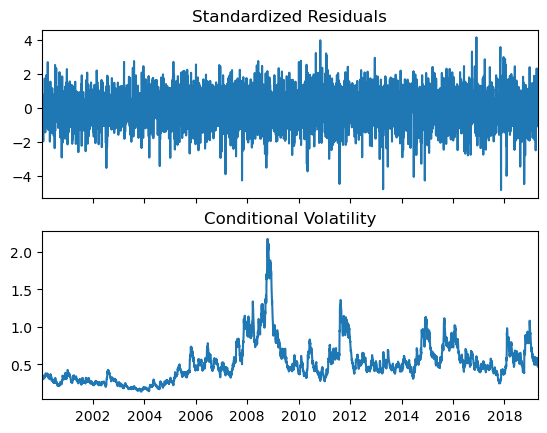

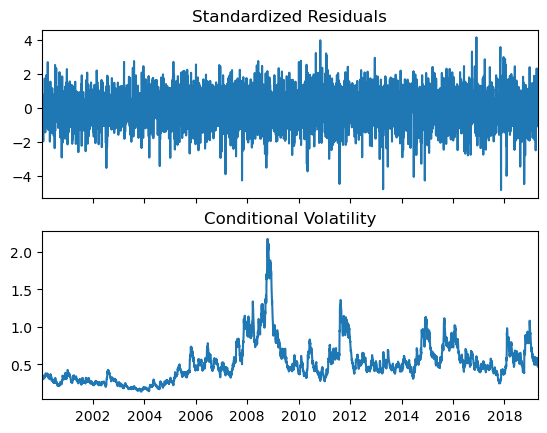

In [88]:
fit.plot()

Ljungbox Test - failed...

In [89]:
lb(fit.resid.dropna(), lags = 10)

,lb_stat,lb_pvalue
1,4.563425,0.032662
2,12.127793,0.002325
3,13.012489,0.004610
4,13.195798,0.010358
5,18.373346,0.002513
6,22.534833,0.000968
7,23.515787,0.001385
8,25.506979,0.001275
9,28.605681,0.000755
10,30.967091,0.000594


In [77]:
pred = []
for i in range(XLE_test.shape[0]):
    roll_XLE_train = XLE.iloc[:len(XLE_train)+i]
    roll_brent_train = brent_returns.iloc[:len(brent_train)+i]
    garch_model = arch_model(roll_XLE_train["Returns"], x = roll_brent_train, mean = "ARX", lags=1, vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
    # garch_model = arch_model(roll_XLE_train["Returns"], vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
    fit = garch_model.fit(disp="off")
    pred.append(fit.forecast(horizon=1, x = roll_brent_train, reindex=True).variance.values[-1][0])
    # pred.append(fit.forecast(horizon=1, reindex=True).variance.values[-1][0])
pred

[0.25303506642536483,
 0.2493041393489053,
 0.3025454548868258,
 0.2991357278736367,
 0.33832673361853494,
 0.3174627623374555,
 0.38659245439144596,
 0.4363066904793333,
 0.409243900534804,
 0.3708423287400287,
 0.3684678926533003,
 0.33778081674512245,
 0.3926297333136236,
 0.38315094242079095,
 0.36981254269114,
 0.3710191945937302,
 0.36488781005569926,
 0.39527705040088595,
 0.5252563313182544,
 0.4764165794507464,
 0.49979751508002096,
 0.48837584228347425,
 0.4985877459702052,
 0.5226369227006266,
 0.5224832777412101,
 0.5228478056899255,
 0.5096133026337839,
 0.5088853584765837,
 0.4662950120919855,
 0.42608294386215595,
 0.39120115492004276,
 0.4042167707187888,
 0.3846454684878794,
 0.37103854074231735,
 0.3564844144783742,
 0.354928935721373,
 0.31967431799595286,
 0.3345105134559764,
 0.32060683445596,
 0.32090098149146634,
 0.33452911501391197,
 0.3377906063467414,
 0.3326065954745702,
 0.32513385098976416,
 0.3052302242458107,
 0.33098351493495165,
 0.3012929608543213,
 0

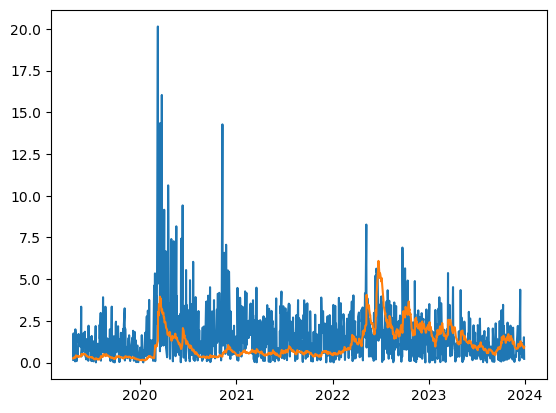

In [78]:
pred_df = pd.Series(pred, index=XLE_test.index)
plt.plot(np.abs(XLE_test["Pct Returns"]))
plt.plot(pred_df)

In [79]:
print(evaluate_rmse(np.abs(XLE_test["Pct Returns"]), pred_df))
print(evaluate_smape(np.abs(XLE_test["Pct Returns"]), pred_df))

('RMSE (squared residuals vs predicted variance):', 1.8580187447028886)
('sMAPE :', 84.73151833222803)


In [82]:
pred_df.to_csv(r"proj/XLE_pred8020.csv")

### 70-30 Train-Test Split

In [83]:
XLE_train2, XLE_test2 = train_test_split(XLE, test_size = 0.3, shuffle=False)
brent_train2, brent_test2 = train_test_split(brent_returns, test_size = 0.3, shuffle=False)

In [94]:
garch_model2 = arch_model(XLE_train2["Returns"], x = brent_train2, mean = "ARX", lags = 1, vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
fit2 = garch_model2.fit(disp='off')
fit2.summary()

c:\Users\Dominique\anaconda3\lib\site-packages\arch\univariate\base.py:1897: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(val[pos], np.float64):
c:\Users\Dominique\anaconda3\lib\site-packages\arch\univariate\base.py:1898: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  converted = format_float_fixed(val[pos], *formats[i])


<class 'statsmodels.iolib.summary.Summary'>
"""
                               AR-X - EGARCH Model Results                               
=========================================================================================
Dep. Variable:                           Returns   R-squared:                       0.093
Mean Model:                                 AR-X   Adj. R-squared:                  0.092
Vol Model:                                EGARCH   Log-Likelihood:               -2505.15
Distribution:      Standardized Skew Student's t   AIC:                           5028.29
Method:                       Maximum Likelihood   BIC:                           5084.90
                                                   No. Observations:                 3983
Date:                           Tue, Oct 29 2024   Df Residuals:                     3980
Time:                                   01:58:56   Df Model:                            3
                                  Mean Model                                  
==============================================================================
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
Const      5.5168e-03  5.569e-03      0.991      0.322  [-5.398e-03,1.643e-02]
Returns[1]    -0.0643  1.541e-02     -4.169  3.063e-05 [-9.446e-02,-3.404e-02]
Price          0.0435  1.784e-03     24.367 3.833e-131   [3.998e-02,4.698e-02]
                                Volatility Model                               
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
omega      -4.9421e-03  2.768e-03     -1.785  7.423e-02  [-1.037e-02,4.839e-04]
alpha[1]        0.1347  1.585e-02      8.493  2.011e-17       [  0.104,  0.166]
gamma[1]       -0.0361  9.596e-03     -3.762  1.687e-04 [-5.491e-02,-1.729e-02]
beta[1]         0.9949  1.602e-03    621.243      0.000       [  0.992,  0.998]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta           14.5559      2.963      4.912  8.995e-07    [  8.748, 20.363]
lambda        -0.1072  2.318e-02     -4.624  3.768e-06 [ -0.153,-6.176e-02]
===========================================================================

Covariance estimator: robust
"""

Ljung-box test - fails again

In [95]:
lb(fit2.resid.dropna(), lags = 10)

,lb_stat,lb_pvalue
1,5.084946,0.024134
2,13.469435,0.001189
3,13.670856,0.003389
4,14.212068,0.006648
5,17.555970,0.003558
6,20.881207,0.001927
7,22.767298,0.001871
8,24.157202,0.002157
9,26.114348,0.001957
10,29.583813,0.001002


In [91]:
pred2 = []
for i in range(XLE_test2.shape[0]):
    roll_XLE_train2 = XLE.iloc[:len(XLE_train2)+i]
    roll_brent_train2 = brent_returns.iloc[:len(brent_train2)+i]
    garch_model = arch_model(roll_XLE_train2["Returns"], x = roll_brent_train2, mean = "ARX", lags = 1, vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
    # garch_model = arch_model(roll_XLE_train["Returns"], vol='EGARCH', p=1, q=1, o=1, dist = 'skewt')
    fit = garch_model.fit(disp="off")
    pred2.append(fit.forecast(horizon=1, x = roll_brent_train2, reindex=True).variance.values[-1][0])
    # pred.append(fit.forecast(horizon=1, reindex=True).variance.values[-1][0])
pred2

[0.26927578755851206,
 0.2580880691326062,
 0.2379722021084721,
 0.21870824739938993,
 0.22797705243187197,
 0.30095057715097207,
 0.27833631765535793,
 0.2565779614269042,
 0.24543699036150024,
 0.23874835336032255,
 0.22352129491529438,
 0.2070014388085215,
 0.18865756063997682,
 0.17427344246994242,
 0.20694418162972242,
 0.19737654800341728,
 0.18968964132037391,
 0.19503664773235146,
 0.17861401105088343,
 0.1732292272187696,
 0.1584561030974095,
 0.19051636315776344,
 0.20436111585570696,
 0.20519993634264846,
 0.20404673632795037,
 0.19567389641379943,
 0.18768233179382676,
 0.17132517736948427,
 0.17173221799497568,
 0.1556076734353582,
 0.17706705572939935,
 0.18125713825562567,
 0.1766915099528734,
 0.1637889284878227,
 0.18032280854763727,
 0.24401011196497877,
 0.22608989794836032,
 0.23762826446473045,
 0.2248970046818343,
 0.22293659619306133,
 0.2276013933818,
 0.2604748089892102,
 0.23512928817000436,
 0.239797347034787,
 0.23037022052724832,
 0.2162130853514107,
 0.199

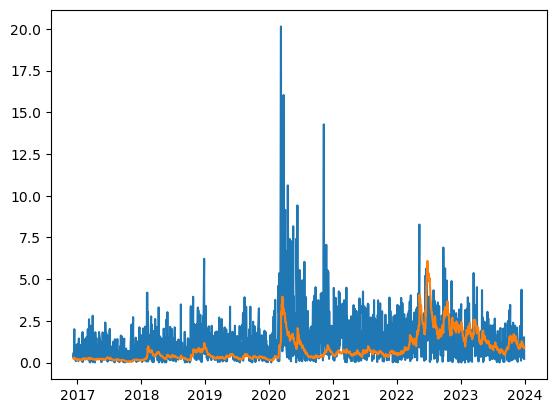

In [92]:
pred_df2 = pd.Series(pred2, index=XLE_test2.index)
plt.plot(np.abs(XLE_test2["Pct Returns"]))
plt.plot(pred_df2)

In [93]:
print(evaluate_rmse(np.abs(XLE_test2["Pct Returns"]), pred_df2))
print(evaluate_smape(np.abs(XLE_test2["Pct Returns"]), pred_df2))

('RMSE (squared residuals vs predicted variance):', 1.6098196037439307)
('sMAPE :', 87.15453137778447)


In [96]:
pred_df2.to_csv(r"C:\Users\Dominique\Desktop\QF603\proj/XLE_pred7030.csv")